# Chess ELO classification with Stockfish move-quality features

This notebook is a second attempt at the chess rating problem. Instead of
using mostly raw SAN move-count features, it uses a chess engine to assign
move-quality features to each player. The key idea is:

1. Stream a small/subsampled Lichess PGN file.
2. Filter bad or misleading games, including provisional/new-player 1500 cases.
3. Use Stockfish to estimate centipawn loss and best-move agreement.
4. Convert each game into two player-centric rows, one for White and one for
   Black.
5. Classify the player's rating band with XGBoost.

This is deliberately **not** set up to process 800,000 games. Engine analysis is
much slower than parsing PGNs, so the default settings are meant for iteration
and diagnostics.

## Notes on dependencies

Python packages used here:

```bash
pip install python-chess zstandard pandas pyarrow tqdm scikit-learn xgboost matplotlib seaborn joblib
```

You also need a Stockfish binary. On many Linux/Colab setups:

```bash
sudo apt-get update
sudo apt-get install -y stockfish
```

If `stockfish` is not on your PATH, set `STOCKFISH_PATH` below manually.

In [1]:
from pathlib import Path
import io
import os
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
import urllib.request
import zstandard as zstd
import chess
import chess.pgn
import chess.engine

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
  accuracy_score,
  balanced_accuracy_score,
  classification_report,
  confusion_matrix,
  log_loss,
)

from xgboost import XGBClassifier
import joblib

warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

## Configuration

The default is a small subset of the April 2014 standard rated Lichess data,
because that is the dataset we have already been using. You can switch to an
earlier month if you want a physically smaller download, but the more important
control is `MAX_GAMES_TO_READ` and `N_GAMES_ENGINE`.

In [2]:
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
MODEL_DIR = DATA_DIR / "models"

for path in [RAW_DIR, PROCESSED_DIR, MODEL_DIR]:
  path.mkdir(parents=True, exist_ok=True)

# Lichess monthly database file.
year = 2014
month = 4

filename = f"lichess_db_standard_rated_{year}-{month:02d}.pgn.zst"
url = f"https://database.lichess.org/standard/{filename}"
zst_path = RAW_DIR / filename

# Keep this modest. PGN parsing is cheap; Stockfish analysis is not.
MAX_GAMES_TO_READ = 36_000
N_GAMES_ENGINE = 6_000

# Analyze only the first N plies of each game. 30 plies = 15 full moves.
# Increasing this improves signal but scales linearly in runtime.
ENGINE_MAX_PLIES = 30
ENGINE_DEPTH = 8
ENGINE_THREADS = 1
ENGINE_HASH_MB = 128

# Cap extreme mate-conversion losses so one forced mate does not dominate.
CP_LOSS_CLIP = 2_000
MATE_SCORE = 100_000

# Change this manually if shutil.which("stockfish") does not find your binary.
STOCKFISH_PATH = os.environ.get("STOCKFISH_PATH") or shutil.which("stockfish")

print("PGN URL:", url)
print("Local path:", zst_path)
print("Stockfish path:", STOCKFISH_PATH)

PGN URL: https://database.lichess.org/standard/lichess_db_standard_rated_2014-04.pgn.zst
Local path: data/raw/lichess_db_standard_rated_2014-04.pgn.zst
Stockfish path: /opt/homebrew/bin/stockfish


## Download PGN file

This cell only downloads the file if it is not already present locally.

In [3]:
if not zst_path.exists():
  print(f"Downloading {filename}...")
  urllib.request.urlretrieve(url, zst_path)
  print("Done.")
else:
  print("File already exists.")

File already exists.


## PGN streaming helpers

The parser streams directly from the `.zst` file, so we do not have to decompress
the whole PGN file to disk.

In [4]:
def iter_pgn_games_from_zst(zst_path, max_games=None):
  """Yield python-chess Game objects from a compressed Lichess PGN file."""
  dctx = zstd.ZstdDecompressor()

  with open(zst_path, "rb") as compressed:
    with dctx.stream_reader(compressed) as reader:
      text_stream = io.TextIOWrapper(reader, encoding="utf-8")

      n_games = 0
      while True:
        game = chess.pgn.read_game(text_stream)

        if game is None:
          break

        yield game
        n_games += 1

        if max_games is not None and n_games >= max_games:
          break


def parse_rating(value):
  """Parse Lichess rating headers, keeping provisional '?' information separate."""
  if value is None:
    return np.nan, False

  text = str(value).strip()
  is_provisional = text.endswith("?")
  text = text.replace("?", "")

  try:
    return float(text), is_provisional
  except ValueError:
    return np.nan, is_provisional


def game_to_light_record(game):
  """Extract metadata plus SAN/UCI moves without doing engine analysis yet."""
  headers = game.headers
  board = game.board()

  moves_san = []
  moves_uci = []

  for move in game.mainline_moves():
    moves_san.append(board.san(move))
    moves_uci.append(move.uci())
    board.push(move)

  white_elo, white_provisional = parse_rating(headers.get("WhiteElo"))
  black_elo, black_provisional = parse_rating(headers.get("BlackElo"))

  return {
    "event": headers.get("Event"),
    "site": headers.get("Site"),
    "date": headers.get("UTCDate", headers.get("Date")),
    "time": headers.get("UTCTime"),
    "white": headers.get("White"),
    "black": headers.get("Black"),
    "result": headers.get("Result"),
    "white_elo": white_elo,
    "black_elo": black_elo,
    "white_provisional": white_provisional,
    "black_provisional": black_provisional,
    "white_rating_diff": headers.get("WhiteRatingDiff"),
    "black_rating_diff": headers.get("BlackRatingDiff"),
    "eco": headers.get("ECO"),
    "opening": headers.get("Opening"),
    "time_control": headers.get("TimeControl"),
    "termination": headers.get("Termination"),
    "num_plies": len(moves_uci),
    "num_full_moves": len(moves_uci) / 2,
    "moves_san": " ".join(moves_san),
    "moves_uci": " ".join(moves_uci),
  }

## Parse a small PGN subset

This is the first quality-of-life improvement: cache the parsed metadata so that
changing the model does not require re-reading PGNs every time.

In [5]:
metadata_path = PROCESSED_DIR / (
  f"lichess_{year}_{month:02d}_metadata_first_{MAX_GAMES_TO_READ}.parquet"
)

if metadata_path.exists():
  df_raw = pd.read_parquet(metadata_path)
  print(f"Loaded cached metadata: {metadata_path}")
else:
  records = []
  game_iter = iter_pgn_games_from_zst(
    zst_path,
    max_games=MAX_GAMES_TO_READ,
  )

  for game in tqdm(game_iter, total=MAX_GAMES_TO_READ):
    records.append(game_to_light_record(game))

  df_raw = pd.DataFrame(records)
  df_raw.to_parquet(metadata_path, index=False)
  print(f"Wrote: {metadata_path}")

df_raw.head()

  0%|          | 0/36000 [00:00<?, ?it/s]

Wrote: data/processed/lichess_2014_04_metadata_first_36000.parquet


,event,site,date,time,white,black,result,white_elo,black_elo,white_provisional,black_provisional,white_rating_diff,black_rating_diff,eco,opening,time_control,termination,num_plies,num_full_moves,moves_san,moves_uci
0,Rated Blitz game,https://lichess.org/ijPYwgVx,2014.03.31,22:01:18,ljubisa2810,amirmahdi,1-0,1806.0,1644.0,False,False,+7,-7,B40,Sicilian Defense: Delayed Alapin Variation,180+0,Normal,45,22.5,e4 e6 Nf3 c5 c3 b6 Bb5 Bb7 O-O Bxe4 d4 Bc6 a4 ...,e2e4 e7e6 g1f3 c7c5 c2c3 b7b6 f1b5 c8b7 e1g1 b...
1,Rated Blitz game,https://lichess.org/y5MMbLnm,2014.03.31,22:00:10,Katapult,dododa,1-0,1905.0,1799.0,False,False,+8,-8,B08,Pirc Defense: Classical Variation,180+0,Normal,61,30.5,e4 d6 Nf3 g6 d4 Bg7 Nc3 Nf6 Bg5 O-O Qe2 Nc6 O-...,e2e4 d7d6 g1f3 g7g6 d2d4 f8g7 b1c3 g8f6 c1g5 e...
2,Rated Blitz game,https://lichess.org/hXbjsQue,2014.03.31,22:00:09,slansson,chycha,1-0,1469.0,1500.0,False,False,+11,-13,C41,Philidor Defense #3,360+0,Time forfeit,95,47.5,e4 e5 Nf3 d6 Bc4 h6 c3 a6 d4 b5 Bb3 Nf6 dxe5 N...,e2e4 e7e5 g1f3 d7d6 f1c4 h7h6 c2c3 a7a6 d2d4 b...
3,Rated Blitz game,https://lichess.org/kf4hwzAq,2014.03.31,22:00:18,NIS,paiaka,1-0,1131.0,1063.0,False,False,+9,-11,C41,Philidor Defense #2,300+0,Time forfeit,13,6.5,e4 e5 Nf3 d6 Nc3 Bg4 Bb5+ c6 Be2 Bxf3 Bxf3 Na6 d3,e2e4 e7e5 g1f3 d7d6 b1c3 c8g4 f1b5 c7c6 b5e2 g...
4,Rated Classical game,https://lichess.org/ZGMLO460,2014.03.31,22:00:33,zinder2,mart1975,1-0,1724.0,1318.0,False,False,+3,-2,B00,Owen Defense,300+8,Normal,41,20.5,e4 b6 d4 Bb7 Nc3 g6 Nf3 Bg7 Bc4 d5 exd5 Nf6 Bb...,e2e4 b7b6 d2d4 c8b7 b1c3 g7g6 g1f3 f8g7 f1c4 d...


## Basic data exploration

We keep the exploratory part because this problem is very sensitive to rating
spikes, short games, time controls, and result imbalance.

In [6]:
print(df_raw.shape)
df_raw.info()

(36000, 21)
<class 'pandas.DataFrame'>
RangeIndex: 36000 entries, 0 to 35999
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   event              36000 non-null  str    
 1   site               36000 non-null  str    
 2   date               36000 non-null  str    
 3   time               36000 non-null  str    
 4   white              36000 non-null  str    
 5   black              36000 non-null  str    
 6   result             36000 non-null  str    
 7   white_elo          36000 non-null  float64
 8   black_elo          35999 non-null  float64
 9   white_provisional  36000 non-null  bool   
 10  black_provisional  36000 non-null  bool   
 11  white_rating_diff  35310 non-null  str    
 12  black_rating_diff  35310 non-null  str    
 13  eco                36000 non-null  str    
 14  opening            36000 non-null  str    
 15  time_control       36000 non-null  str    
 16  termination        36

In [7]:
inspect_cols = [
  "white_elo",
  "black_elo",
  "result",
  "eco",
  "opening",
  "time_control",
  "termination",
  "num_plies",
  "white_provisional",
  "black_provisional",
]

df_raw[inspect_cols].head(20)

,white_elo,black_elo,result,eco,opening,time_control,termination,num_plies,white_provisional,black_provisional
0,1806.0,1644.0,1-0,B40,Sicilian Defense: Delayed Alapin Variation,180+0,Normal,45,False,False
1,1905.0,1799.0,1-0,B08,Pirc Defense: Classical Variation,180+0,Normal,61,False,False
2,1469.0,1500.0,1-0,C41,Philidor Defense #3,360+0,Time forfeit,95,False,False
3,1131.0,1063.0,1-0,C41,Philidor Defense #2,300+0,Time forfeit,13,False,False
4,1724.0,1318.0,1-0,B00,Owen Defense,300+8,Normal,41,False,False
5,1612.0,1923.0,0-1,B01,Scandinavian Defense,60+0,Normal,76,False,False
6,1458.0,1586.0,0-1,B00,Caro-Kann Defense: Hillbilly Attack,420+11,Normal,107,False,False
7,1241.0,1355.0,0-1,A30,English Opening: Symmetrical Variation,60+0,Time forfeit,34,False,False
8,1467.0,1151.0,1-0,A46,Yusupov-Rubinstein System,60+1,Time forfeit,29,False,False
9,1877.0,1843.0,0-1,C00,French Defense: Normal Variation,60+1,Normal,48,False,False


In [8]:
df_raw[["white_elo", "black_elo", "num_plies"]].describe()

,white_elo,black_elo,num_plies
count,36000.000000,35999.000000,36000.000000
mean,1618.628306,1608.431901,67.247083
std,222.736420,227.052382,32.428636
min,796.000000,796.000000,0.000000
25%,1472.000000,1460.000000,45.000000
50%,1618.000000,1608.000000,64.000000
75%,1766.000000,1759.000000,86.000000
max,2611.000000,2608.000000,292.000000


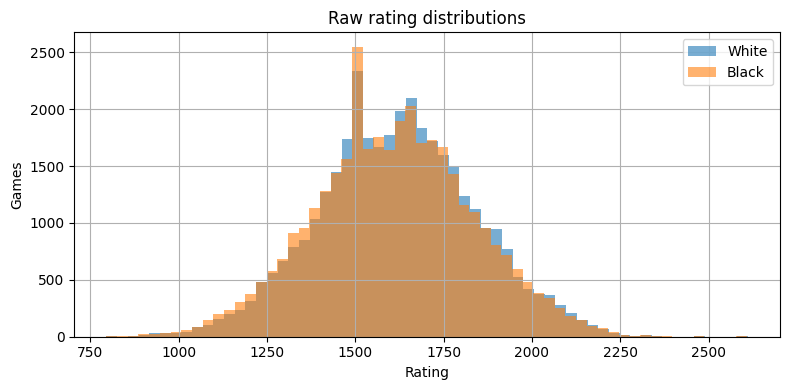

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
df_raw["white_elo"].hist(bins=60, alpha=0.6, ax=ax, label="White")
df_raw["black_elo"].hist(bins=60, alpha=0.6, ax=ax, label="Black")
ax.set_xlabel("Rating")
ax.set_ylabel("Games")
ax.set_title("Raw rating distributions")
ax.legend()
plt.tight_layout()
plt.show()

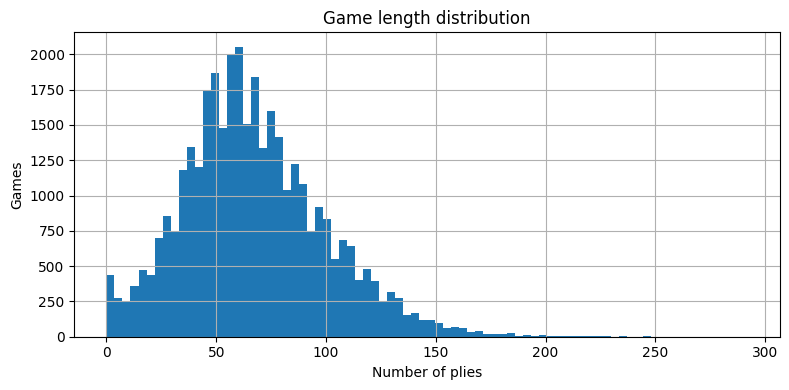

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
df_raw["num_plies"].hist(bins=80, ax=ax)
ax.set_xlabel("Number of plies")
ax.set_ylabel("Games")
ax.set_title("Game length distribution")
plt.tight_layout()
plt.show()

In [11]:
print("Results:")
display(df_raw["result"].value_counts(dropna=False).to_frame("count"))

print("\nTermination:")
display(df_raw["termination"].value_counts(dropna=False).head(20).to_frame("count"))

print("\nTime controls:")
display(df_raw["time_control"].value_counts(dropna=False).head(20).to_frame("count"))

print("\nOpenings:")
display(df_raw["opening"].value_counts(dropna=False).head(20).to_frame("count"))

Results:


,count
result,
1-0,18305
0-1,16474
1/2-1/2,1221



Termination:


,count
termination,
Normal,24004
Time forfeit,11989
Rules infraction,7



Time controls:


,count
time_control,
60+0,4013
300+0,3746
180+0,2779
120+0,2198
300+8,1986
600+0,1433
240+0,1365
0+1,1364
60+1,1137



Openings:


,count
opening,
Van't Kruijs Opening,1015
Modern Defense,680
Horwitz Defense,654
Scandinavian Defense: Mieses-Kotroc Variation,559
French Defense: Knight Variation,557
Owen Defense,554
Caro-Kann Defense,547
Bishop's Opening,510
Sicilian Defense: Bowdler Attack,495


## Filter obvious data issues

The exact 1500 spike is suspicious in old Lichess data because new/provisional
accounts start there. We remove exact 1500 ratings by default and also remove
ratings explicitly marked as provisional with `?` when present.

In [12]:
MIN_PLIES = 20
REMOVE_EXACT_1500 = True
REMOVE_PROVISIONAL = True

valid_mask = (
  df_raw["white_elo"].notna()
  & df_raw["black_elo"].notna()
  & df_raw["result"].isin(["1-0", "0-1", "1/2-1/2"])
  & df_raw["moves_uci"].notna()
  & df_raw["num_plies"].ge(MIN_PLIES)
)

if REMOVE_EXACT_1500:
  valid_mask &= ~(
    df_raw["white_elo"].eq(1500)
    | df_raw["black_elo"].eq(1500)
  )

if REMOVE_PROVISIONAL:
  valid_mask &= ~(
    df_raw["white_provisional"].fillna(False)
    | df_raw["black_provisional"].fillna(False)
  )

df_games = df_raw.loc[valid_mask].copy()

print("Rows before filtering:", len(df_raw))
print("Rows after filtering: ", len(df_games))
print("Removed:              ", len(df_raw) - len(df_games))

df_games[["white_elo", "black_elo", "num_plies"]].describe()

Rows before filtering: 36000
Rows after filtering:  32549
Removed:               3451


,white_elo,black_elo,num_plies
count,32549.000000,32549.000000,32549.00000
mean,1629.003810,1621.022796,70.76285
std,221.709161,225.635519,30.21533
min,884.000000,850.000000,20.00000
25%,1476.000000,1467.000000,49.00000
50%,1632.000000,1625.000000,66.00000
75%,1776.000000,1771.000000,88.00000
max,2611.000000,2608.000000,292.00000


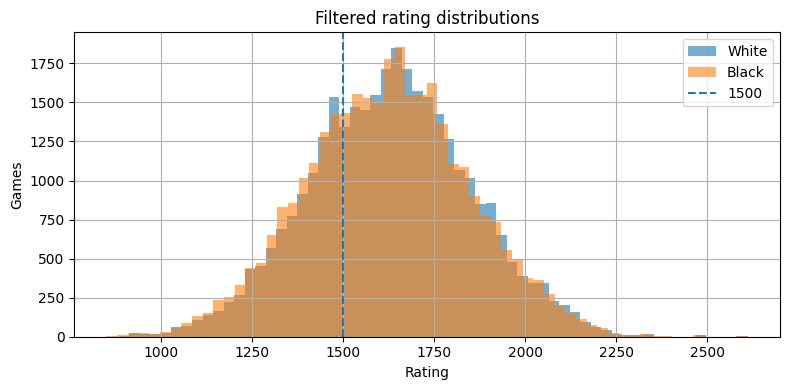

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
df_games["white_elo"].hist(bins=60, alpha=0.6, ax=ax, label="White")
df_games["black_elo"].hist(bins=60, alpha=0.6, ax=ax, label="Black")
ax.axvline(1500, linestyle="--", label="1500")
ax.set_xlabel("Rating")
ax.set_ylabel("Games")
ax.set_title("Filtered rating distributions")
ax.legend()
plt.tight_layout()
plt.show()

## Draw a small engine-analysis sample

Engine analysis is the bottleneck. To keep class balance reasonable, we sample
from broad average-rating bins rather than simply taking the first `N` games.

In [14]:
def add_average_rating_bin(df):
  df = df.copy()

  df["white_elo"] = pd.to_numeric(df["white_elo"], errors="coerce")
  df["black_elo"] = pd.to_numeric(df["black_elo"], errors="coerce")
  df["avg_elo"] = (df["white_elo"] + df["black_elo"]) / 2

  df["avg_elo_bin"] = pd.cut(
    df["avg_elo"],
    bins=[0, 1200, 1500, 1800, 2100, 3000],
    labels=["<1200", "1200-1499", "1500-1799", "1800-2099", "2100+"],
    include_lowest=True,
    right=False,
  )

  return df


df_games = add_average_rating_bin(df_games)

print("Full parsed game table:")
print(df_games.shape)
display(
  df_games["avg_elo_bin"]
  .value_counts(dropna=False)
  .sort_index()
  .to_frame("games")
)

# Keep only games with valid ratings and valid rating bin.
df_games_with_elo = (
  df_games
  .dropna(subset=["white_elo", "black_elo", "avg_elo", "avg_elo_bin"])
  .copy()
  .reset_index(drop=True)
)

print("After ELO filtering:")
print(df_games_with_elo.shape)
display(
  df_games_with_elo["avg_elo_bin"]
  .value_counts(dropna=False)
  .sort_index()
  .to_frame("games")
)

sample_size = min(N_GAMES_ENGINE, len(df_games_with_elo))

if sample_size == 0:
  raise ValueError("No valid games remain after ELO filtering.")

# Stratified sample. This version avoids groupby/apply index weirdness.
sampled_parts = []

for bin_name, g in df_games_with_elo.groupby("avg_elo_bin", observed=True):
  n_bin = round(sample_size * len(g) / len(df_games_with_elo))
  n_bin = max(1, n_bin)
  n_bin = min(n_bin, len(g))

  sampled_parts.append(
    g.sample(n=n_bin, random_state=RANDOM_STATE)
  )

df_engine_input = pd.concat(sampled_parts, axis=0)

# Trim or top up from the FILTERED dataframe only.
if len(df_engine_input) > sample_size:
  df_engine_input = df_engine_input.sample(
    n=sample_size,
    random_state=RANDOM_STATE,
  )

elif len(df_engine_input) < sample_size:
  missing = sample_size - len(df_engine_input)

  remaining_pool = df_games_with_elo.drop(df_engine_input.index)

  extra = remaining_pool.sample(
    n=min(missing, len(remaining_pool)),
    random_state=RANDOM_STATE,
  )

  df_engine_input = pd.concat([df_engine_input, extra], axis=0)

df_engine_input = (
  df_engine_input
  .sample(frac=1, random_state=RANDOM_STATE)
  .reset_index(drop=True)
  .copy()
)

# Hard checks so we fail here, not 20 cells later.
assert len(df_engine_input) == sample_size
assert df_engine_input["white_elo"].notna().all()
assert df_engine_input["black_elo"].notna().all()
assert df_engine_input["avg_elo"].notna().all()
assert df_engine_input["avg_elo_bin"].notna().all()

print("Final engine input:")
print(df_engine_input.shape)
display(
  df_engine_input["avg_elo_bin"]
  .value_counts(dropna=False)
  .sort_index()
  .to_frame("games")
)

Full parsed game table:
(32549, 23)


,games
avg_elo_bin,
<1200,543
1200-1499,8436
1500-1799,17012
1800-2099,6187
2100+,371


After ELO filtering:
(32549, 23)


,games
avg_elo_bin,
<1200,543
1200-1499,8436
1500-1799,17012
1800-2099,6187
2100+,371


Final engine input:
(6000, 23)


,games
avg_elo_bin,
<1200,100
1200-1499,1556
1500-1799,3136
1800-2099,1140
2100+,68


## Stockfish feature extraction

For each move, we compare the engine's best-line evaluation before the move to
the evaluation after the actual played move. From the moving player's
perspective:

`centipawn_loss = best_position_eval_before_move - eval_after_played_move`

This is clipped to avoid one mate sequence dominating all summary statistics.
The output is one row per game with separate White/Black engine summaries.

In [15]:
def require_stockfish_path(stockfish_path):
  if stockfish_path is None:
    raise FileNotFoundError(
      "Stockfish was not found. Install it or set STOCKFISH_PATH manually."
    )

  path = Path(stockfish_path)
  if not path.exists() and shutil.which(str(stockfish_path)) is None:
    raise FileNotFoundError(
      f"Stockfish path does not exist: {stockfish_path}"
    )


def score_to_cp(score, pov_color):
  """Convert a python-chess PovScore/Score to centipawns from pov_color."""
  return score.pov(pov_color).score(mate_score=MATE_SCORE)


def summarize_cp_losses(losses, prefix):
  losses = np.asarray(losses, dtype=float)

  if len(losses) == 0:
    return {
      f"{prefix}_moves_analyzed": 0,
      f"{prefix}_acpl": np.nan,
      f"{prefix}_median_cpl": np.nan,
      f"{prefix}_std_cpl": np.nan,
      f"{prefix}_p75_cpl": np.nan,
      f"{prefix}_p90_cpl": np.nan,
      f"{prefix}_max_cpl": np.nan,
      f"{prefix}_inaccuracy_rate": np.nan,
      f"{prefix}_mistake_rate": np.nan,
      f"{prefix}_blunder_rate": np.nan,
    }

  return {
    f"{prefix}_moves_analyzed": len(losses),
    f"{prefix}_acpl": float(np.mean(losses)),
    f"{prefix}_median_cpl": float(np.median(losses)),
    f"{prefix}_std_cpl": float(np.std(losses)),
    f"{prefix}_p75_cpl": float(np.percentile(losses, 75)),
    f"{prefix}_p90_cpl": float(np.percentile(losses, 90)),
    f"{prefix}_max_cpl": float(np.max(losses)),
    f"{prefix}_inaccuracy_rate": float(np.mean(losses >= 50)),
    f"{prefix}_mistake_rate": float(np.mean(losses >= 100)),
    f"{prefix}_blunder_rate": float(np.mean(losses >= 300)),
  }


def phase_summaries(losses_by_ply, prefix):
  """Summarize opening/middlegame/endgame losses by absolute ply index."""
  out = {}
  phases = {
    "opening": lambda ply: ply <= 10,
    "middlegame": lambda ply: 10 < ply <= 30,
    "late": lambda ply: ply > 30,
  }

  for phase, selector in phases.items():
    phase_losses = [loss for ply, loss in losses_by_ply if selector(ply)]
    if len(phase_losses) == 0:
      out[f"{prefix}_{phase}_acpl"] = np.nan
    else:
      out[f"{prefix}_{phase}_acpl"] = float(np.mean(phase_losses))

  return out


def result_for_color(result, color):
  if result == "1-0":
    return 1.0 if color == chess.WHITE else 0.0
  if result == "0-1":
    return 0.0 if color == chess.WHITE else 1.0
  if result == "1/2-1/2":
    return 0.5
  return np.nan

In [16]:
def analyze_game_with_engine(row, engine, max_plies=30, depth=8):
  """Analyze one game row and return game-level engine features."""
  board = chess.Board()
  moves = []

  for uci in str(row["moves_uci"]).split():
    try:
      move = chess.Move.from_uci(uci)
    except ValueError:
      break

    if move not in board.legal_moves:
      break

    moves.append(move)
    board.push(move)

  board.reset()

  losses = {
    chess.WHITE: [],
    chess.BLACK: [],
  }
  losses_by_ply = {
    chess.WHITE: [],
    chess.BLACK: [],
  }
  best_matches = {
    chess.WHITE: [],
    chess.BLACK: [],
  }
  eval_before_values = {
    chess.WHITE: [],
    chess.BLACK: [],
  }

  limit = chess.engine.Limit(depth=depth)

  for ply_idx, move in enumerate(moves[:max_plies], start=1):
    mover = board.turn

    info_before = engine.analyse(board, limit)
    best_score_cp = score_to_cp(info_before["score"], mover)
    best_move = None
    if "pv" in info_before and len(info_before["pv"]) > 0:
      best_move = info_before["pv"][0]

    board.push(move)

    info_after = engine.analyse(board, limit)
    played_score_cp = score_to_cp(info_after["score"], mover)

    cp_loss = best_score_cp - played_score_cp
    cp_loss = max(0, cp_loss)
    cp_loss = min(cp_loss, CP_LOSS_CLIP)

    losses[mover].append(cp_loss)
    losses_by_ply[mover].append((ply_idx, cp_loss))
    eval_before_values[mover].append(best_score_cp)
    best_matches[mover].append(float(best_move == move) if best_move else np.nan)

  out = {
    "game_index": row.name,
    "white_elo": row["white_elo"],
    "black_elo": row["black_elo"],
    "result": row["result"],
    "eco": row["eco"],
    "opening": row["opening"],
    "time_control": row["time_control"],
    "termination": row["termination"],
    "num_plies": row["num_plies"],
    "num_full_moves": row["num_full_moves"],
    "engine_plies_analyzed": min(len(moves), max_plies),
  }

  for color, prefix in [(chess.WHITE, "white"), (chess.BLACK, "black")]:
    out.update(summarize_cp_losses(losses[color], prefix))
    out.update(phase_summaries(losses_by_ply[color], prefix))

    matches = np.asarray(best_matches[color], dtype=float)
    evals = np.asarray(eval_before_values[color], dtype=float)

    out[f"{prefix}_best_move_rate"] = (
      float(np.nanmean(matches)) if len(matches) else np.nan
    )
    out[f"{prefix}_mean_eval_before"] = (
      float(np.nanmean(evals)) if len(evals) else np.nan
    )
    out[f"{prefix}_result_score"] = result_for_color(row["result"], color)

  out["acpl_gap_white_minus_black"] = out["white_acpl"] - out["black_acpl"]
  out["best_move_rate_gap_white_minus_black"] = (
    out["white_best_move_rate"] - out["black_best_move_rate"]
  )

  return out

## Run or load cached Stockfish analysis

This cell can take several minutes depending on `N_GAMES_ENGINE`,
`ENGINE_MAX_PLIES`, and `ENGINE_DEPTH`. The result is cached as Parquet.

In [17]:
engine_features_path = PROCESSED_DIR / (
  f"lichess_{year}_{month:02d}_stockfish_features_"
  f"games{len(df_engine_input)}_plies{ENGINE_MAX_PLIES}_depth{ENGINE_DEPTH}.parquet"
)

if engine_features_path.exists():
  df_engine = pd.read_parquet(engine_features_path)
  print(f"Loaded cached engine features: {engine_features_path}")
else:
  require_stockfish_path(STOCKFISH_PATH)

  engine = chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH)
  engine.configure({
    "Threads": ENGINE_THREADS,
    "Hash": ENGINE_HASH_MB,
  })

  feature_records = []
  try:
    for _, row in tqdm(
      df_engine_input.iterrows(),
      total=len(df_engine_input),
      desc="Stockfish analysis",
    ):
      try:
        feature_records.append(
          analyze_game_with_engine(
            row,
            engine=engine,
            max_plies=ENGINE_MAX_PLIES,
            depth=ENGINE_DEPTH,
          )
        )
      except Exception as exc:
        print(f"Skipping game index {row.name}: {exc}")
  finally:
    engine.quit()

  df_engine = pd.DataFrame(feature_records)
  df_engine.to_parquet(engine_features_path, index=False)
  print(f"Wrote: {engine_features_path}")

df_engine.head()

Stockfish analysis:   0%|          | 0/6000 [00:00<?, ?it/s]

Wrote: data/processed/lichess_2014_04_stockfish_features_games6000_plies30_depth8.parquet


,game_index,white_elo,black_elo,result,eco,opening,time_control,termination,num_plies,num_full_moves,engine_plies_analyzed,white_moves_analyzed,white_acpl,white_median_cpl,white_std_cpl,white_p75_cpl,white_p90_cpl,white_max_cpl,white_inaccuracy_rate,white_mistake_rate,white_blunder_rate,white_opening_acpl,white_middlegame_acpl,white_late_acpl,white_best_move_rate,white_mean_eval_before,white_result_score,black_moves_analyzed,black_acpl,black_median_cpl,black_std_cpl,black_p75_cpl,black_p90_cpl,black_max_cpl,black_inaccuracy_rate,black_mistake_rate,black_blunder_rate,black_opening_acpl,black_middlegame_acpl,black_late_acpl,black_best_move_rate,black_mean_eval_before,black_result_score,acpl_gap_white_minus_black,best_move_rate_gap_white_minus_black
0,0,1839.0,1606.0,1-0,D20,Queen's Gambit Accepted: Old Variation,300+8,Normal,77,38.5,30,15,30.466667,6.0,75.970930,19.5,44.6,309.0,0.133333,0.066667,0.066667,3.6,43.9,NaN,0.466667,206.200000,1.0,15,79.933333,38.0,105.792543,122.0,238.6,331.0,0.400000,0.266667,0.066667,16.8,111.5,NaN,0.200000,-182.066667,0.0,-49.466667,0.266667
1,1,1577.0,1504.0,0-1,C58,"Italian Game: Two Knights Defense, Polerio Def...",60+1,Normal,54,27.0,30,15,30.466667,6.0,35.590011,61.5,83.4,93.0,0.400000,0.000000,0.000000,34.6,28.4,NaN,0.533333,77.666667,0.0,15,24.866667,10.0,27.417432,44.5,59.0,91.0,0.133333,0.000000,0.000000,11.2,31.7,NaN,0.533333,-54.866667,1.0,5.600000,0.000000
2,2,1379.0,1435.0,1-0,C00,French Defense: Queen's Knight,300+2,Time forfeit,31,15.5,30,15,52.466667,29.0,59.503352,65.0,129.8,215.0,0.466667,0.200000,0.000000,18.4,69.5,NaN,0.333333,-78.533333,1.0,15,21.533333,0.0,30.068514,34.0,49.2,111.0,0.133333,0.066667,0.000000,18.4,23.1,NaN,0.466667,129.400000,0.0,30.933333,-0.133333
3,3,1518.0,1668.0,1-0,A00,Van't Kruijs Opening,240+0,Time forfeit,139,69.5,30,15,39.066667,40.0,29.428935,61.5,72.4,92.0,0.466667,0.000000,0.000000,25.8,45.7,NaN,0.133333,10.600000,1.0,15,45.866667,22.0,55.184378,87.0,113.0,179.0,0.400000,0.266667,0.000000,17.6,60.0,NaN,0.333333,27.466667,0.0,-6.800000,-0.200000
4,4,1844.0,1976.0,1-0,B12,Caro-Kann Defense: Goldman Variation,480+0,Time forfeit,79,39.5,30,15,42.533333,17.0,74.862422,48.5,85.2,301.0,0.200000,0.133333,0.066667,32.0,47.8,NaN,0.400000,82.266667,1.0,15,34.866667,7.0,78.932770,27.0,37.8,326.0,0.066667,0.066667,0.066667,14.4,45.1,NaN,0.466667,-43.400000,0.0,7.666667,-0.066667


## Explore engine-derived features

Now we can check whether the engine features have sensible distributions and
whether they visibly separate rating groups.

In [18]:
df_engine.shape

(6000, 45)

In [19]:
engine_summary_cols = [
  "white_acpl",
  "black_acpl",
  "white_best_move_rate",
  "black_best_move_rate",
  "white_blunder_rate",
  "black_blunder_rate",
  "acpl_gap_white_minus_black",
  "engine_plies_analyzed",
]

df_engine[engine_summary_cols].describe()

,white_acpl,black_acpl,white_best_move_rate,black_best_move_rate,white_blunder_rate,black_blunder_rate,acpl_gap_white_minus_black,engine_plies_analyzed
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,47.986955,50.309219,0.348668,0.338506,0.020861,0.023380,-2.322264,29.715167
std,41.136654,45.271447,0.136750,0.140914,0.043653,0.047678,34.226160,1.356593
min,3.333333,1.800000,0.000000,0.000000,0.000000,0.000000,-285.118182,20.000000
25%,26.266667,26.533333,0.266667,0.266667,0.000000,0.000000,-14.266667,30.000000
50%,39.000000,40.533333,0.333333,0.333333,0.000000,0.000000,-1.000000,30.000000
75%,58.283333,61.400000,0.466667,0.400000,0.000000,0.066667,10.733333,30.000000
max,1617.600000,1770.533333,1.000000,0.866667,0.800000,0.933333,248.200000,30.000000


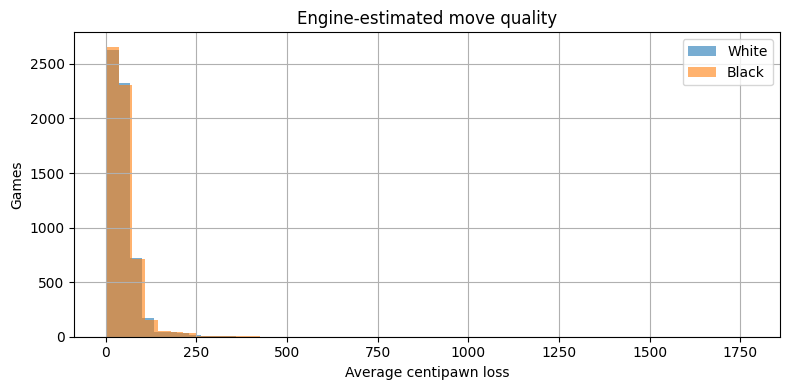

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
df_engine["white_acpl"].hist(bins=50, alpha=0.6, ax=ax, label="White")
df_engine["black_acpl"].hist(bins=50, alpha=0.6, ax=ax, label="Black")
ax.set_xlabel("Average centipawn loss")
ax.set_ylabel("Games")
ax.set_title("Engine-estimated move quality")
ax.legend()
plt.tight_layout()
plt.show()

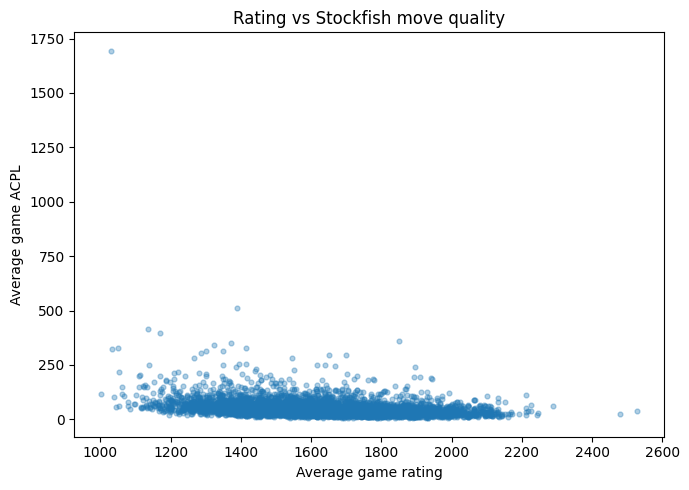

In [21]:
plot_df = df_engine.copy()
plot_df["avg_elo"] = (plot_df["white_elo"] + plot_df["black_elo"]) / 2
plot_df["avg_acpl"] = (plot_df["white_acpl"] + plot_df["black_acpl"]) / 2

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(plot_df["avg_elo"], plot_df["avg_acpl"], alpha=0.35, s=12)
ax.set_xlabel("Average game rating")
ax.set_ylabel("Average game ACPL")
ax.set_title("Rating vs Stockfish move quality")
plt.tight_layout()
plt.show()

In [22]:
# Correlations give a quick sanity check. We expect better players to have
# lower ACPL and fewer blunders, though the relationship will be noisy.
corr_cols = [
  "white_elo",
  "black_elo",
  "white_acpl",
  "black_acpl",
  "white_best_move_rate",
  "black_best_move_rate",
  "white_blunder_rate",
  "black_blunder_rate",
  "num_plies",
]

df_engine[corr_cols].corr(numeric_only=True).round(3)

,white_elo,black_elo,white_acpl,black_acpl,white_best_move_rate,black_best_move_rate,white_blunder_rate,black_blunder_rate,num_plies
white_elo,1.000,0.681,-0.282,-0.216,0.155,0.094,-0.234,-0.198,0.103
black_elo,0.681,1.000,-0.223,-0.293,0.052,0.181,-0.188,-0.253,0.107
white_acpl,-0.282,-0.223,1.000,0.690,-0.232,-0.044,0.740,0.526,-0.171
black_acpl,-0.216,-0.293,0.690,1.000,-0.016,-0.253,0.494,0.781,-0.200
white_best_move_rate,0.155,0.052,-0.232,-0.016,1.000,0.182,-0.133,-0.020,-0.032
black_best_move_rate,0.094,0.181,-0.044,-0.253,0.182,1.000,-0.000,-0.148,-0.003
white_blunder_rate,-0.234,-0.188,0.740,0.494,-0.133,-0.000,1.000,0.539,-0.138
black_blunder_rate,-0.198,-0.253,0.526,0.781,-0.020,-0.148,0.539,1.000,-0.168
num_plies,0.103,0.107,-0.171,-0.200,-0.032,-0.003,-0.138,-0.168,1.000


## Convert games into player-centric classification rows

Each game becomes two rows:

- one row for White, target = White's rating band;
- one row for Black, target = Black's rating band.

This makes the task closer to: "Given how this player moved in the game, what
rating band do they belong to?"

In [23]:
RATING_BINS = [0, 1200, 1500, 1800, 2100, 3000]
RATING_LABELS = ["<1200", "1200-1499", "1500-1799", "1800-2099", "2100+"]

own_suffixes = [
  "moves_analyzed",
  "acpl",
  "median_cpl",
  "std_cpl",
  "p75_cpl",
  "p90_cpl",
  "max_cpl",
  "inaccuracy_rate",
  "mistake_rate",
  "blunder_rate",
  "opening_acpl",
  "middlegame_acpl",
  "late_acpl",
  "best_move_rate",
  "mean_eval_before",
  "result_score",
]


def make_player_rows(df):
  rows = []

  for _, row in df.iterrows():
    for color_name, opp_name, is_white in [
      ("white", "black", 1),
      ("black", "white", 0),
    ]:
      player_rating = row[f"{color_name}_elo"]

      out = {
        "rating": player_rating,
        "rating_bin": pd.cut(
          [player_rating],
          bins=RATING_BINS,
          labels=RATING_LABELS,
          include_lowest=True,
        )[0],
        "is_white": is_white,
        "result": row["result"],
        "eco": row["eco"],
        "time_control": row["time_control"],
        "termination": row["termination"],
        "num_plies": row["num_plies"],
        "num_full_moves": row["num_full_moves"],
        "engine_plies_analyzed": row["engine_plies_analyzed"],
      }

      for suffix in own_suffixes:
        out[f"own_{suffix}"] = row[f"{color_name}_{suffix}"]
        out[f"opp_{suffix}"] = row[f"{opp_name}_{suffix}"]

      out["own_minus_opp_acpl"] = out["own_acpl"] - out["opp_acpl"]
      out["own_minus_opp_best_move_rate"] = (
        out["own_best_move_rate"] - out["opp_best_move_rate"]
      )
      out["own_minus_opp_blunder_rate"] = (
        out["own_blunder_rate"] - out["opp_blunder_rate"]
      )

      rows.append(out)

  return pd.DataFrame(rows)


df_player = make_player_rows(df_engine)

df_player.head()

,rating,rating_bin,is_white,result,eco,time_control,termination,num_plies,num_full_moves,engine_plies_analyzed,own_moves_analyzed,opp_moves_analyzed,own_acpl,opp_acpl,own_median_cpl,opp_median_cpl,own_std_cpl,opp_std_cpl,own_p75_cpl,opp_p75_cpl,own_p90_cpl,opp_p90_cpl,own_max_cpl,opp_max_cpl,own_inaccuracy_rate,opp_inaccuracy_rate,own_mistake_rate,opp_mistake_rate,own_blunder_rate,opp_blunder_rate,own_opening_acpl,opp_opening_acpl,own_middlegame_acpl,opp_middlegame_acpl,own_late_acpl,opp_late_acpl,own_best_move_rate,opp_best_move_rate,own_mean_eval_before,opp_mean_eval_before,own_result_score,opp_result_score,own_minus_opp_acpl,own_minus_opp_best_move_rate,own_minus_opp_blunder_rate
0,1839.0,1800-2099,1,1-0,D20,300+8,Normal,77,38.5,30,15,15,30.466667,79.933333,6.0,38.0,75.970930,105.792543,19.5,122.0,44.6,238.6,309.0,331.0,0.133333,0.400000,0.066667,0.266667,0.066667,0.066667,3.6,16.8,43.9,111.5,NaN,NaN,0.466667,0.200000,206.200000,-182.066667,1.0,0.0,-49.466667,0.266667,0.0
1,1606.0,1500-1799,0,1-0,D20,300+8,Normal,77,38.5,30,15,15,79.933333,30.466667,38.0,6.0,105.792543,75.970930,122.0,19.5,238.6,44.6,331.0,309.0,0.400000,0.133333,0.266667,0.066667,0.066667,0.066667,16.8,3.6,111.5,43.9,NaN,NaN,0.200000,0.466667,-182.066667,206.200000,0.0,1.0,49.466667,-0.266667,0.0
2,1577.0,1500-1799,1,0-1,C58,60+1,Normal,54,27.0,30,15,15,30.466667,24.866667,6.0,10.0,35.590011,27.417432,61.5,44.5,83.4,59.0,93.0,91.0,0.400000,0.133333,0.000000,0.000000,0.000000,0.000000,34.6,11.2,28.4,31.7,NaN,NaN,0.533333,0.533333,77.666667,-54.866667,0.0,1.0,5.600000,0.000000,0.0
3,1504.0,1500-1799,0,0-1,C58,60+1,Normal,54,27.0,30,15,15,24.866667,30.466667,10.0,6.0,27.417432,35.590011,44.5,61.5,59.0,83.4,91.0,93.0,0.133333,0.400000,0.000000,0.000000,0.000000,0.000000,11.2,34.6,31.7,28.4,NaN,NaN,0.533333,0.533333,-54.866667,77.666667,1.0,0.0,-5.600000,0.000000,0.0
4,1379.0,1200-1499,1,1-0,C00,300+2,Time forfeit,31,15.5,30,15,15,52.466667,21.533333,29.0,0.0,59.503352,30.068514,65.0,34.0,129.8,49.2,215.0,111.0,0.466667,0.133333,0.200000,0.066667,0.000000,0.000000,18.4,18.4,69.5,23.1,NaN,NaN,0.333333,0.466667,-78.533333,129.400000,1.0,0.0,30.933333,-0.133333,0.0


In [24]:
print(df_player.shape)
display(df_player["rating_bin"].value_counts(dropna=False).sort_index().to_frame("players"))
df_player[["rating", "own_acpl", "own_best_move_rate", "own_blunder_rate"]].describe()

(12000, 45)


,players
rating_bin,
1200-1499,3160
1500-1799,5889
1800-2099,2406
2100+,203
<1200,342


,rating,own_acpl,own_best_move_rate,own_blunder_rate
count,12000.000000,12000.000000,12000.000000,12000.000000
mean,1627.314750,49.148087,0.343587,0.022120
std,224.774842,43.267269,0.138934,0.045725
min,866.000000,1.800000,0.000000,0.000000
25%,1472.000000,26.400000,0.266667,0.000000
50%,1633.000000,39.800000,0.333333,0.000000
75%,1778.000000,59.800000,0.466667,0.000000
max,2601.000000,1770.533333,1.000000,0.933333


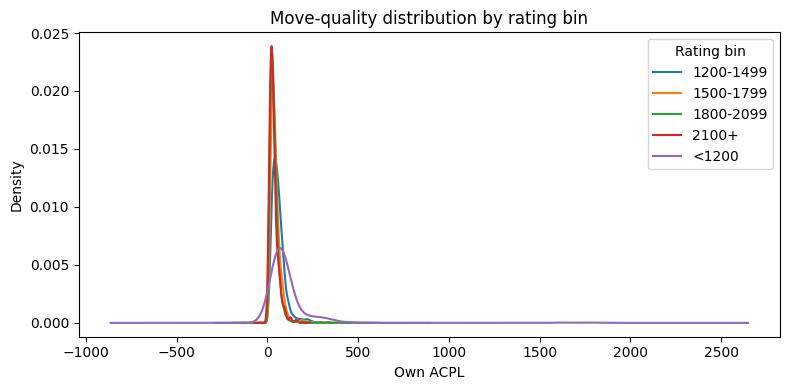

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
for label, group in df_player.groupby("rating_bin", observed=False):
  group["own_acpl"].plot(kind="kde", ax=ax, label=str(label))
ax.set_xlabel("Own ACPL")
ax.set_title("Move-quality distribution by rating bin")
ax.legend(title="Rating bin")
plt.tight_layout()
plt.show()

## Select features and targets

We intentionally do **not** use usernames, exact ratings, or rating differences.
The classifier sees move-quality summaries plus basic game metadata.

In [26]:
target_col = "rating_bin"

numeric_features = [
  "is_white",
  "num_plies",
  "num_full_moves",
  "engine_plies_analyzed",
  "own_moves_analyzed",
  "opp_moves_analyzed",
  "own_acpl",
  "opp_acpl",
  "own_median_cpl",
  "opp_median_cpl",
  "own_std_cpl",
  "opp_std_cpl",
  "own_p75_cpl",
  "opp_p75_cpl",
  "own_p90_cpl",
  "opp_p90_cpl",
  "own_max_cpl",
  "opp_max_cpl",
  "own_inaccuracy_rate",
  "opp_inaccuracy_rate",
  "own_mistake_rate",
  "opp_mistake_rate",
  "own_blunder_rate",
  "opp_blunder_rate",
  "own_opening_acpl",
  "opp_opening_acpl",
  "own_middlegame_acpl",
  "opp_middlegame_acpl",
  "own_late_acpl",
  "opp_late_acpl",
  "own_best_move_rate",
  "opp_best_move_rate",
  "own_mean_eval_before",
  "opp_mean_eval_before",
  "own_result_score",
  "opp_result_score",
  "own_minus_opp_acpl",
  "own_minus_opp_best_move_rate",
  "own_minus_opp_blunder_rate",
]

categorical_features = [
  "result",
  "eco",
  "time_control",
  "termination",
]

model_df = df_player.dropna(subset=[target_col]).copy()

# Keep only classes with enough examples for stratified splitting.
min_class_count = 10
class_counts = model_df[target_col].value_counts()
valid_classes = class_counts[class_counts >= min_class_count].index
model_df = model_df[model_df[target_col].isin(valid_classes)].copy()

print("Class counts after rare-class filtering:")
display(model_df[target_col].value_counts().sort_index().to_frame("players"))

Class counts after rare-class filtering:


,players
rating_bin,
1200-1499,3160
1500-1799,5889
1800-2099,2406
2100+,203
<1200,342


In [27]:
X_raw = model_df[numeric_features + categorical_features].copy()
y_raw = model_df[target_col].astype(str).copy()

# Simple imputation. Tree models tolerate rough imputations well, but they do
# not accept NaNs in every configuration/version.
for col in numeric_features:
  X_raw[col] = X_raw[col].replace([np.inf, -np.inf], np.nan)
  X_raw[col] = X_raw[col].fillna(X_raw[col].median())

for col in categorical_features:
  X_raw[col] = X_raw[col].fillna("MISSING").astype(str)

X = pd.get_dummies(
  X_raw,
  columns=categorical_features,
  dummy_na=False,
)

X.columns = (
  X.columns
  .astype(str)
  .str.replace("[", "(", regex=False)
  .str.replace("]", ")", regex=False)
  .str.replace("<", "lt", regex=False)
  .str.replace(">", "gt", regex=False)
)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

print("Examples:", X.shape[0])
print("Features:", X.shape[1])
print("Classes:", list(label_encoder.classes_))
X.head()

Examples: 12000
Features: 519
Classes: ['1200-1499', '1500-1799', '1800-2099', '2100+', '<1200']


,is_white,num_plies,num_full_moves,engine_plies_analyzed,own_moves_analyzed,opp_moves_analyzed,own_acpl,opp_acpl,own_median_cpl,opp_median_cpl,own_std_cpl,opp_std_cpl,own_p75_cpl,opp_p75_cpl,own_p90_cpl,opp_p90_cpl,own_max_cpl,opp_max_cpl,own_inaccuracy_rate,opp_inaccuracy_rate,own_mistake_rate,opp_mistake_rate,own_blunder_rate,opp_blunder_rate,own_opening_acpl,opp_opening_acpl,own_middlegame_acpl,opp_middlegame_acpl,own_late_acpl,opp_late_acpl,own_best_move_rate,opp_best_move_rate,own_mean_eval_before,opp_mean_eval_before,own_result_score,opp_result_score,own_minus_opp_acpl,own_minus_opp_best_move_rate,own_minus_opp_blunder_rate,result_0-1,result_1-0,result_1/2-1/2,eco_A00,eco_A01,eco_A02,eco_A03,eco_A04,eco_A05,eco_A06,eco_A07,eco_A08,eco_A09,eco_A10,eco_A11,eco_A12,eco_A13,eco_A15,eco_A16,eco_A17,eco_A18,...,time_control_600+2,time_control_600+20,time_control_600+3,time_control_600+30,time_control_600+4,time_control_600+5,time_control_600+6,time_control_600+7,time_control_600+8,time_control_660+1,time_control_660+11,time_control_660+2,time_control_660+25,time_control_660+5,time_control_660+7,time_control_660+8,time_control_720+0,time_control_720+1,time_control_720+10,time_control_720+12,time_control_720+3,time_control_720+30,time_control_720+4,time_control_720+5,time_control_720+6,time_control_720+7,time_control_720+8,time_control_720+9,time_control_7200+10,time_control_780+0,time_control_780+10,time_control_780+14,time_control_780+15,time_control_780+2,time_control_780+5,time_control_780+8,time_control_840+0,time_control_840+10,time_control_840+12,time_control_840+2,time_control_840+6,time_control_840+8,time_control_900+0,time_control_900+1,time_control_900+10,time_control_900+12,time_control_900+13,time_control_900+15,time_control_900+2,time_control_900+20,time_control_900+3,time_control_900+4,time_control_900+5,time_control_900+6,time_control_900+7,time_control_900+8,time_control_960+0,time_control_960+6,termination_Normal,termination_Time forfeit
0,1,77,38.5,30,15,15,30.466667,79.933333,6.0,38.0,75.970930,105.792543,19.5,122.0,44.6,238.6,309.0,331.0,0.133333,0.400000,0.066667,0.266667,0.066667,0.066667,3.6,16.8,43.9,111.5,NaN,NaN,0.466667,0.200000,206.200000,-182.066667,1.0,0.0,-49.466667,0.266667,0.0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,0,77,38.5,30,15,15,79.933333,30.466667,38.0,6.0,105.792543,75.970930,122.0,19.5,238.6,44.6,331.0,309.0,0.400000,0.133333,0.266667,0.066667,0.066667,0.066667,16.8,3.6,111.5,43.9,NaN,NaN,0.200000,0.466667,-182.066667,206.200000,0.0,1.0,49.466667,-0.266667,0.0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,1,54,27.0,30,15,15,30.466667,24.866667,6.0,10.0,35.590011,27.417432,61.5,44.5,83.4,59.0,93.0,91.0,0.400000,0.133333,0.000000,0.000000,0.000000,0.000000,34.6,11.2,28.4,31.7,NaN,NaN,0.533333,0.533333,77.666667,-54.866667,0.0,1.0,5.600000,0.000000,0.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fals

## Train / validation / test split

We use stratified splits because class imbalance is common after binning ELO.

In [28]:
X_train, X_rem, y_train, y_rem = train_test_split(
  X,
  y,
  train_size=0.70,
  random_state=RANDOM_STATE,
  stratify=y,
)

X_valid, X_test, y_valid, y_test = train_test_split(
  X_rem,
  y_rem,
  train_size=0.50,
  random_state=RANDOM_STATE,
  stratify=y_rem,
)

print("Train:", X_train.shape, np.bincount(y_train))
print("Valid:", X_valid.shape, np.bincount(y_valid))
print("Test: ", X_test.shape, np.bincount(y_test))

Train: (8400, 519) [2212 4122 1684  142  240]
Valid: (1800, 519) [474 883 361  31  51]
Test:  (1800, 519) [474 884 361  30  51]


## Baselines

A majority-class baseline is essential. If XGBoost cannot beat this, the engine
features are not yet useful enough or the target bins are too fine.

In [29]:
def evaluate_classifier(y_true, pred, proba, label):
  print(label)
  print("-" * len(label))
  print(f"Accuracy:          {accuracy_score(y_true, pred):.4f}")
  print(f"Balanced accuracy: {balanced_accuracy_score(y_true, pred):.4f}")

  if proba is not None:
    print(f"Log loss:          {log_loss(y_true, proba, labels=np.arange(len(label_encoder.classes_))):.4f}")

  print()
  print(classification_report(
    y_true,
    pred,
    target_names=label_encoder.classes_,
    zero_division=0,
  ))


def plot_confusion(y_true, pred, title):
  cm = confusion_matrix(y_true, pred)

  fig, ax = plt.subplots(figsize=(7, 6))
  im = ax.imshow(cm)
  ax.set_xticks(np.arange(len(label_encoder.classes_)))
  ax.set_yticks(np.arange(len(label_encoder.classes_)))
  ax.set_xticklabels(label_encoder.classes_, rotation=45, ha="right")
  ax.set_yticklabels(label_encoder.classes_)
  ax.set_xlabel("Predicted")
  ax.set_ylabel("True")
  ax.set_title(title)

  for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
      ax.text(j, i, cm[i, j], ha="center", va="center")

  fig.colorbar(im, ax=ax)
  plt.tight_layout()
  plt.show()

In [30]:
majority_class = np.bincount(y_train).argmax()
valid_majority_pred = np.full_like(y_valid, fill_value=majority_class)
test_majority_pred = np.full_like(y_test, fill_value=majority_class)

majority_proba_valid = np.zeros((len(y_valid), len(label_encoder.classes_)))
majority_proba_valid[:, majority_class] = 1.0

majority_proba_test = np.zeros((len(y_test), len(label_encoder.classes_)))
majority_proba_test[:, majority_class] = 1.0

evaluate_classifier(
  y_valid,
  valid_majority_pred,
  majority_proba_valid,
  "Validation majority-class baseline",
)

Validation majority-class baseline
----------------------------------
Accuracy:          0.4906
Balanced accuracy: 0.2000
Log loss:          18.3622

              precision    recall  f1-score   support

   1200-1499       0.00      0.00      0.00       474
   1500-1799       0.49      1.00      0.66       883
   1800-2099       0.00      0.00      0.00       361
       2100+       0.00      0.00      0.00        31
       <1200       0.00      0.00      0.00        51

    accuracy                           0.49      1800
   macro avg       0.10      0.20      0.13      1800
weighted avg       0.24      0.49      0.32      1800



## XGBoost classifier

This is intentionally modest. Once the feature pipeline looks reasonable, tune
`max_depth`, `min_child_weight`, `subsample`, `colsample_bytree`, and
`n_estimators`.

In [31]:
xgb_clf = XGBClassifier(
  objective="multi:softprob",
  num_class=len(label_encoder.classes_),
  eval_metric="mlogloss",
  n_estimators=350,
  max_depth=3,
  learning_rate=0.04,
  subsample=0.85,
  colsample_bytree=0.85,
  min_child_weight=3,
  reg_lambda=3.0,
  reg_alpha=0.0,
  random_state=RANDOM_STATE,
  n_jobs=-1,
)

xgb_clf.fit(
  X_train,
  y_train,
  eval_set=[(X_train, y_train), (X_valid, y_valid)],
  verbose=False,
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.85
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

Validation XGBoost
------------------
Accuracy:          0.5178
Balanced accuracy: 0.2724
Log loss:          1.0608

              precision    recall  f1-score   support

   1200-1499       0.49      0.30      0.37       474
   1500-1799       0.53      0.83      0.65       883
   1800-2099       0.47      0.14      0.21       361
       2100+       1.00      0.03      0.06        31
       <1200       0.50      0.06      0.11        51

    accuracy                           0.52      1800
   macro avg       0.60      0.27      0.28      1800
weighted avg       0.51      0.52      0.46      1800



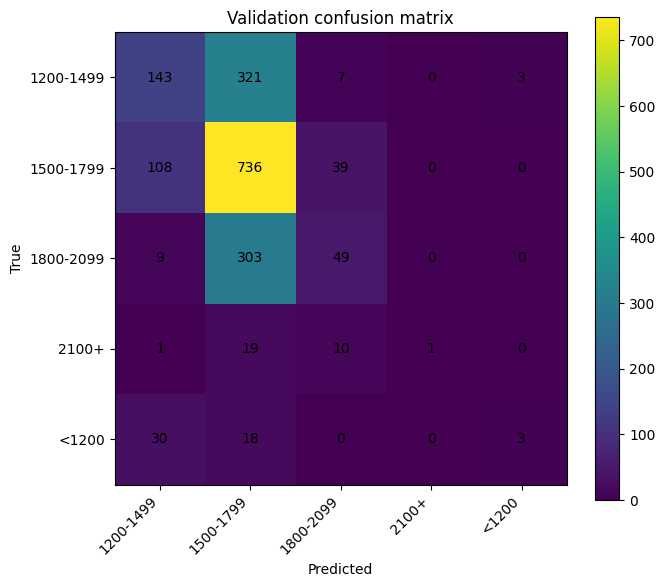

In [32]:
valid_proba = xgb_clf.predict_proba(X_valid)
test_proba = xgb_clf.predict_proba(X_test)

valid_pred = valid_proba.argmax(axis=1)
test_pred = test_proba.argmax(axis=1)

evaluate_classifier(
  y_valid,
  valid_pred,
  valid_proba,
  "Validation XGBoost",
)

plot_confusion(y_valid, valid_pred, "Validation confusion matrix")

Test XGBoost
------------
Accuracy:          0.5172
Balanced accuracy: 0.2636
Log loss:          1.0504

              precision    recall  f1-score   support

   1200-1499       0.49      0.34      0.40       474
   1500-1799       0.53      0.81      0.64       884
   1800-2099       0.49      0.15      0.23       361
       2100+       0.00      0.00      0.00        30
       <1200       0.25      0.02      0.04        51

    accuracy                           0.52      1800
   macro avg       0.35      0.26      0.26      1800
weighted avg       0.49      0.52      0.47      1800



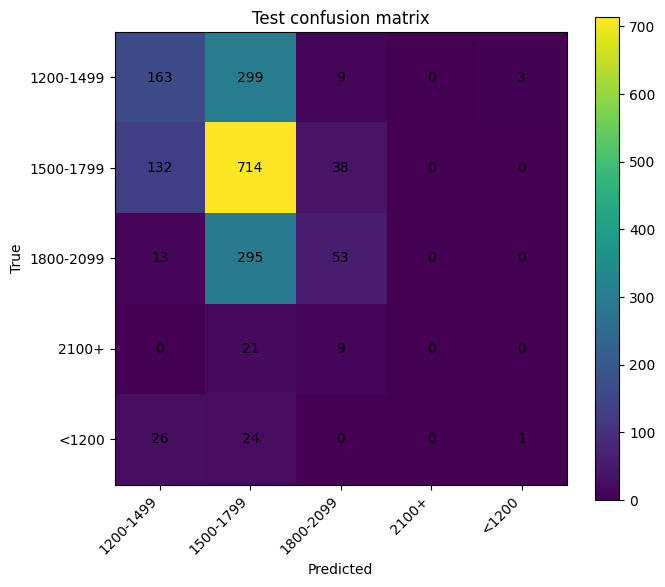

In [33]:
evaluate_classifier(
  y_test,
  test_pred,
  test_proba,
  "Test XGBoost",
)

plot_confusion(y_test, test_pred, "Test confusion matrix")

## Inspect prediction confidence and errors

Adjacent-bin mistakes are less bad than predicting `<1200` for a `2100+` player,
so we inspect both predicted labels and ordinal class distance.

In [34]:
pred_df = pd.DataFrame({
  "true_label": label_encoder.inverse_transform(y_test),
  "pred_label": label_encoder.inverse_transform(test_pred),
  "true_code": y_test,
  "pred_code": test_pred,
  "max_proba": test_proba.max(axis=1),
})

pred_df["class_distance"] = (pred_df["pred_code"] - pred_df["true_code"]).abs()

for class_idx, class_name in enumerate(label_encoder.classes_):
  pred_df[f"proba_{class_name}"] = test_proba[:, class_idx]

pred_df.head(20)

,true_label,pred_label,true_code,pred_code,max_proba,class_distance,proba_1200-1499,proba_1500-1799,proba_1800-2099,proba_2100+,proba_<1200
0,1500-1799,1500-1799,1,1,0.619588,0,0.170036,0.619588,0.197144,0.006871,0.006361
1,1500-1799,1500-1799,1,1,0.571633,0,0.160164,0.571633,0.248847,0.014590,0.004765
2,1500-1799,1500-1799,1,1,0.602639,0,0.159071,0.602639,0.219104,0.015357,0.003829
3,1800-2099,1800-2099,2,2,0.499897,0,0.074753,0.363149,0.499897,0.059493,0.002709
4,1200-1499,1500-1799,0,1,0.592977,1,0.269236,0.592977,0.128740,0.004365,0.004682
5,1500-1799,1500-1799,1,1,0.479293,0,0.360216,0.479293,0.136171,0.006806,0.017515
6,<1200,1500-1799,4,1,0.596223,3,0.197093,0.596223,0.189543,0.004670,0.012471
7,1500-1799,1500-1799,1,1,0.644992,0,0.162391,0.644992,0.182072,0.003325,0.007219
8,1500-1799,1200-1499,1,0,0.571123,1,0.571123,0.338443,0.086901,0.001802,0.001732
9,1200-1499,1200-1499,0,0,0.586257,0,0.586257,0.234933,0.042262,0.001790,0.134758


In [35]:
pred_df["class_distance"].value_counts().sort_index().to_frame("count")

,count
class_distance,
0,931
1,773
2,43
3,24
4,29


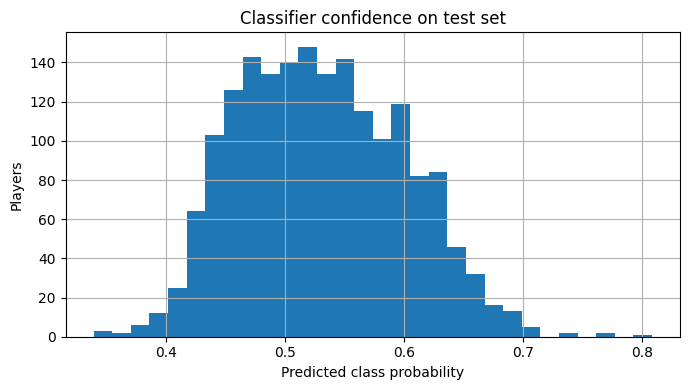

In [36]:
fig, ax = plt.subplots(figsize=(7, 4))
pred_df["max_proba"].hist(bins=30, ax=ax)
ax.set_xlabel("Predicted class probability")
ax.set_ylabel("Players")
ax.set_title("Classifier confidence on test set")
plt.tight_layout()
plt.show()

## Learning curves from XGBoost eval history

This replaces the previous regression loss check with multiclass log-loss.

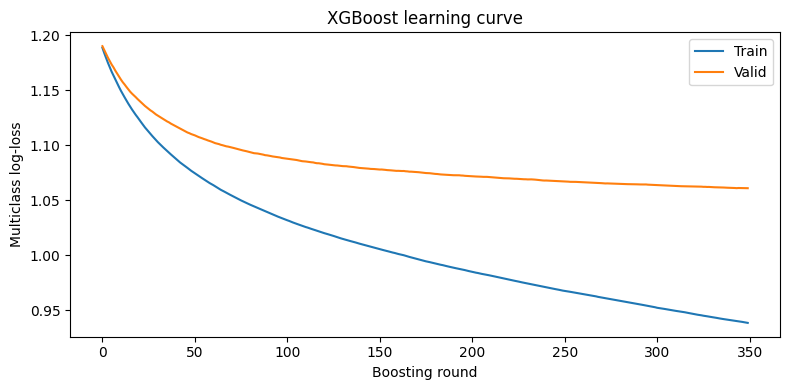

In [37]:
results = xgb_clf.evals_result()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results["validation_0"]["mlogloss"], label="Train")
ax.plot(results["validation_1"]["mlogloss"], label="Valid")
ax.set_xlabel("Boosting round")
ax.set_ylabel("Multiclass log-loss")
ax.set_title("XGBoost learning curve")
ax.legend()
plt.tight_layout()
plt.show()

## Feature importance

This checks whether the model is actually using engine-derived features rather
than only metadata such as time control or opening.

In [38]:
importance_df = pd.DataFrame({
  "feature": X_train.columns,
  "importance": xgb_clf.feature_importances_,
})

importance_df = importance_df.sort_values("importance", ascending=False)
importance_df.head(30)

,feature,importance
6,own_acpl,0.045009
441,time_control_60+0,0.015209
12,own_p75_cpl,0.015111
18,own_inaccuracy_rate,0.014381
442,time_control_60+1,0.014306
302,time_control_0+3,0.013340
393,time_control_300+5,0.011918
347,time_control_180+0,0.011019
178,eco_C20,0.010791
24,own_opening_acpl,0.010100


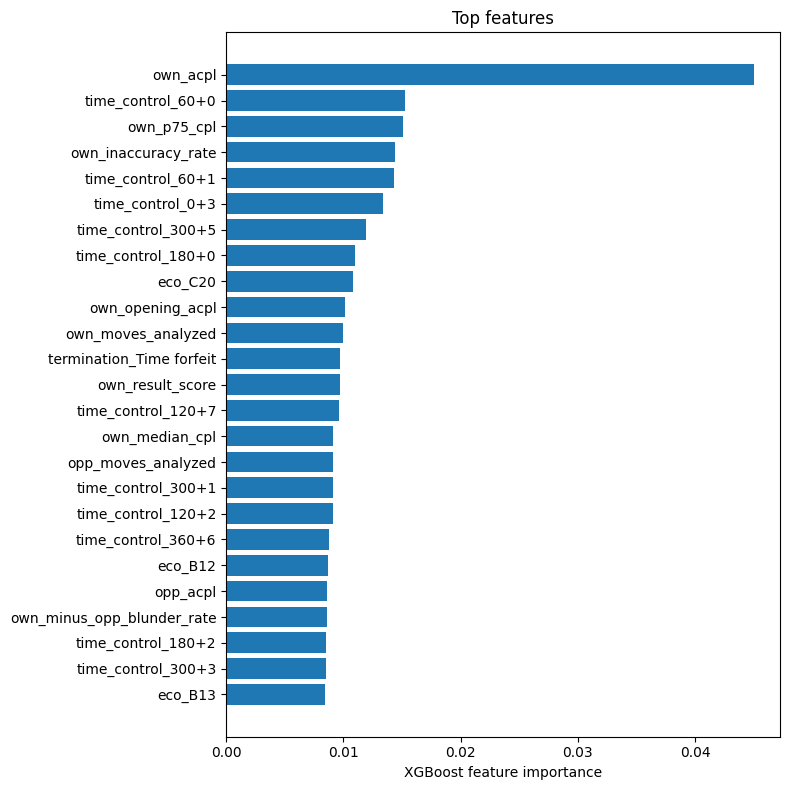

In [39]:
top_importance = importance_df.head(25).copy()

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(
  top_importance["feature"][::-1],
  top_importance["importance"][::-1],
)
ax.set_xlabel("XGBoost feature importance")
ax.set_title("Top features")
plt.tight_layout()
plt.show()

## Save artifacts

The cached engine feature table is usually the most valuable output. The model
and feature list are saved for later reuse.

In [40]:
model_path = MODEL_DIR / "xgb_stockfish_elo_classifier.joblib"
features_path = MODEL_DIR / "xgb_stockfish_elo_classifier_features.joblib"
label_encoder_path = MODEL_DIR / "xgb_stockfish_elo_classifier_label_encoder.joblib"
player_table_path = PROCESSED_DIR / "stockfish_player_rows.parquet"

joblib.dump(xgb_clf, model_path)
joblib.dump(list(X_train.columns), features_path)
joblib.dump(label_encoder, label_encoder_path)
df_player.to_parquet(player_table_path, index=False)

print(f"Wrote: {model_path}")
print(f"Wrote: {features_path}")
print(f"Wrote: {label_encoder_path}")
print(f"Wrote: {player_table_path}")

Wrote: data/models/xgb_stockfish_elo_classifier.joblib
Wrote: data/models/xgb_stockfish_elo_classifier_features.joblib
Wrote: data/models/xgb_stockfish_elo_classifier_label_encoder.joblib
Wrote: data/processed/stockfish_player_rows.parquet


## Suggested next experiments

1. Increase `N_GAMES_ENGINE` to 2,000-5,000 after the pipeline works.
2. Compare `ENGINE_DEPTH=6`, `8`, and `10` on the same game sample.
3. Try coarser rating bins if adjacent-bin confusion dominates.
4. Try only the first 10, 20, or 30 plies to see whether openings are enough.
5. Add separate opening-only features and compare against engine-only features.
6. Consider predicting a player's **relative** rating bin versus opponent rather
   than absolute ELO.